In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

In [15]:
df = pd.read_csv('skab_valve_1.csv', sep=';', parse_dates=['datetime'])

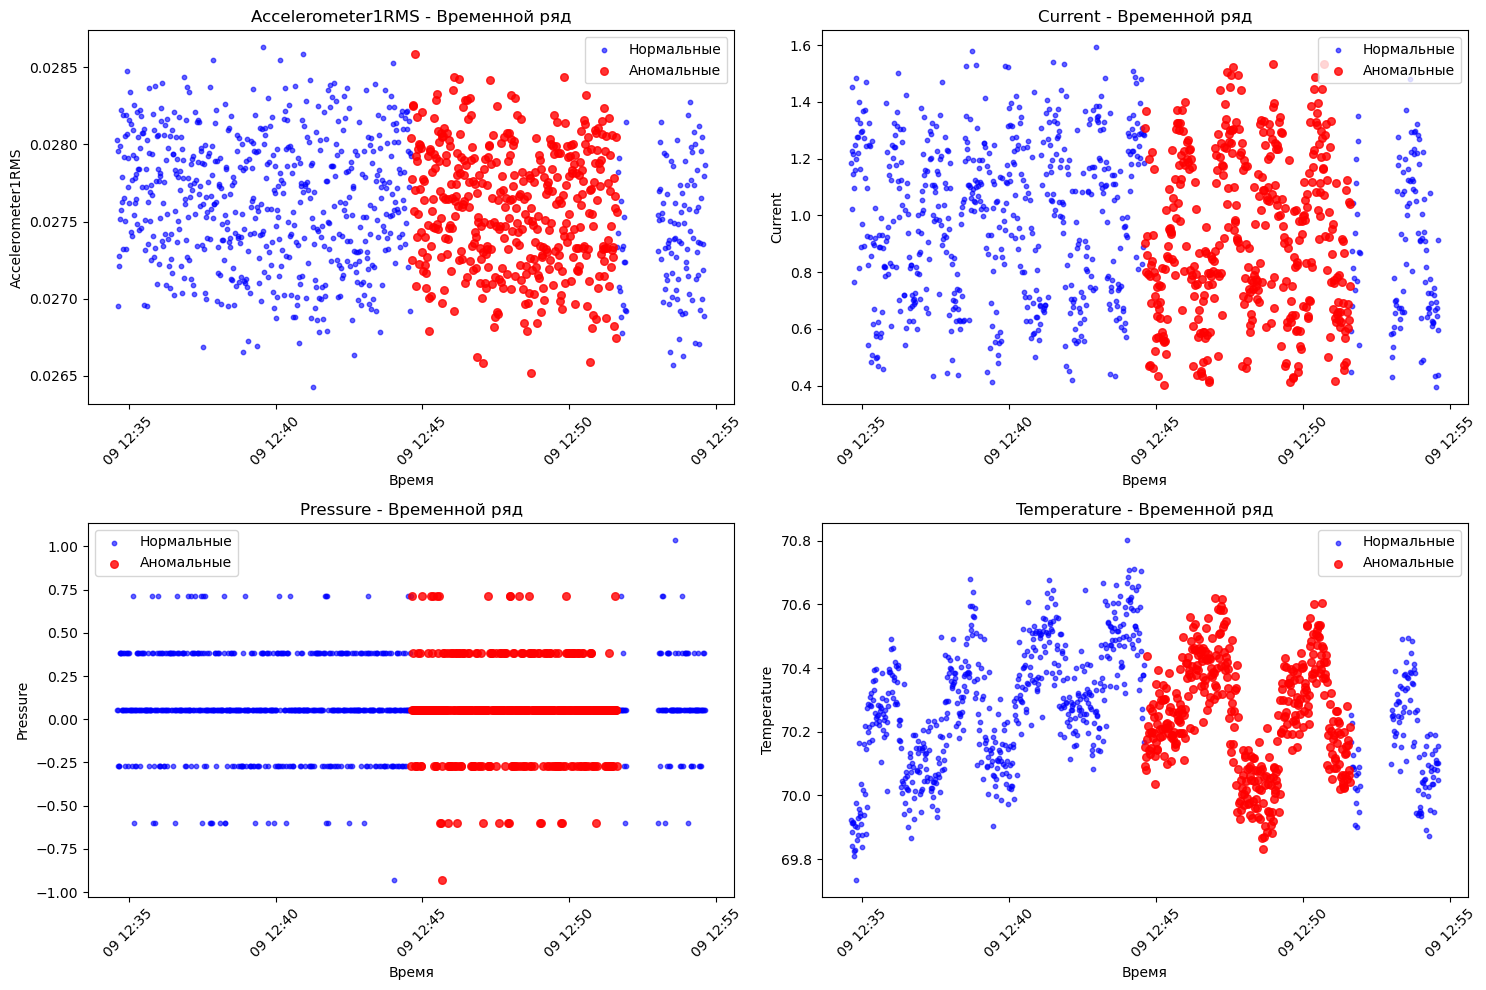

In [16]:
plt.figure(figsize=(15, 10))

# Выберем несколько ключевых параметров для визуализации
features_to_plot = ['Accelerometer1RMS', 'Current', 'Pressure', 'Temperature']

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    
    # Нормальные точки
    normal_data = df[df['anomaly'] == 0]
    plt.scatter(normal_data['datetime'], normal_data[feature], 
                alpha=0.6, s=10, label='Нормальные', color='blue')
    
    # Аномальные точки
    anomaly_data = df[df['anomaly'] == 1]
    plt.scatter(anomaly_data['datetime'], anomaly_data[feature], 
                alpha=0.8, s=30, label='Аномальные', color='red')
    
    plt.title(f'{feature} - Временной ряд')
    plt.xlabel('Время')
    plt.ylabel(feature)
    plt.legend()
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [17]:
def detect_anomalies_iqr(data, features, multiplier=1.5):
    """
    Обнаружение аномалий с помощью метода IQR
    """
    anomalies = pd.Series([0] * len(data), index=data.index)
    
    for feature in features:
        Q1 = data[feature].quantile(0.25)
        Q3 = data[feature].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        
        feature_anomalies = (data[feature] < lower_bound) | (data[feature] > upper_bound)
        anomalies = anomalies | feature_anomalies
    
    return anomalies.astype(int)

# Выберем числовые признаки для анализа
numeric_features = ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 
                   'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS']

# Применяем IQR метод с разными множителями
df['anomaly_iqr_1.5'] = detect_anomalies_iqr(df, numeric_features, multiplier=1.5)
df['anomaly_iqr_3.0'] = detect_anomalies_iqr(df, numeric_features, multiplier=3.0)

print("Результаты IQR метода:")
print(f"IQR 1.5: обнаружено {df['anomaly_iqr_1.5'].sum()} аномалий")
print(f"IQR 3.0: обнаружено {df['anomaly_iqr_3.0'].sum()} аномалий")

Результаты IQR метода:
IQR 1.5: обнаружено 105 аномалий
IQR 3.0: обнаружено 2 аномалий


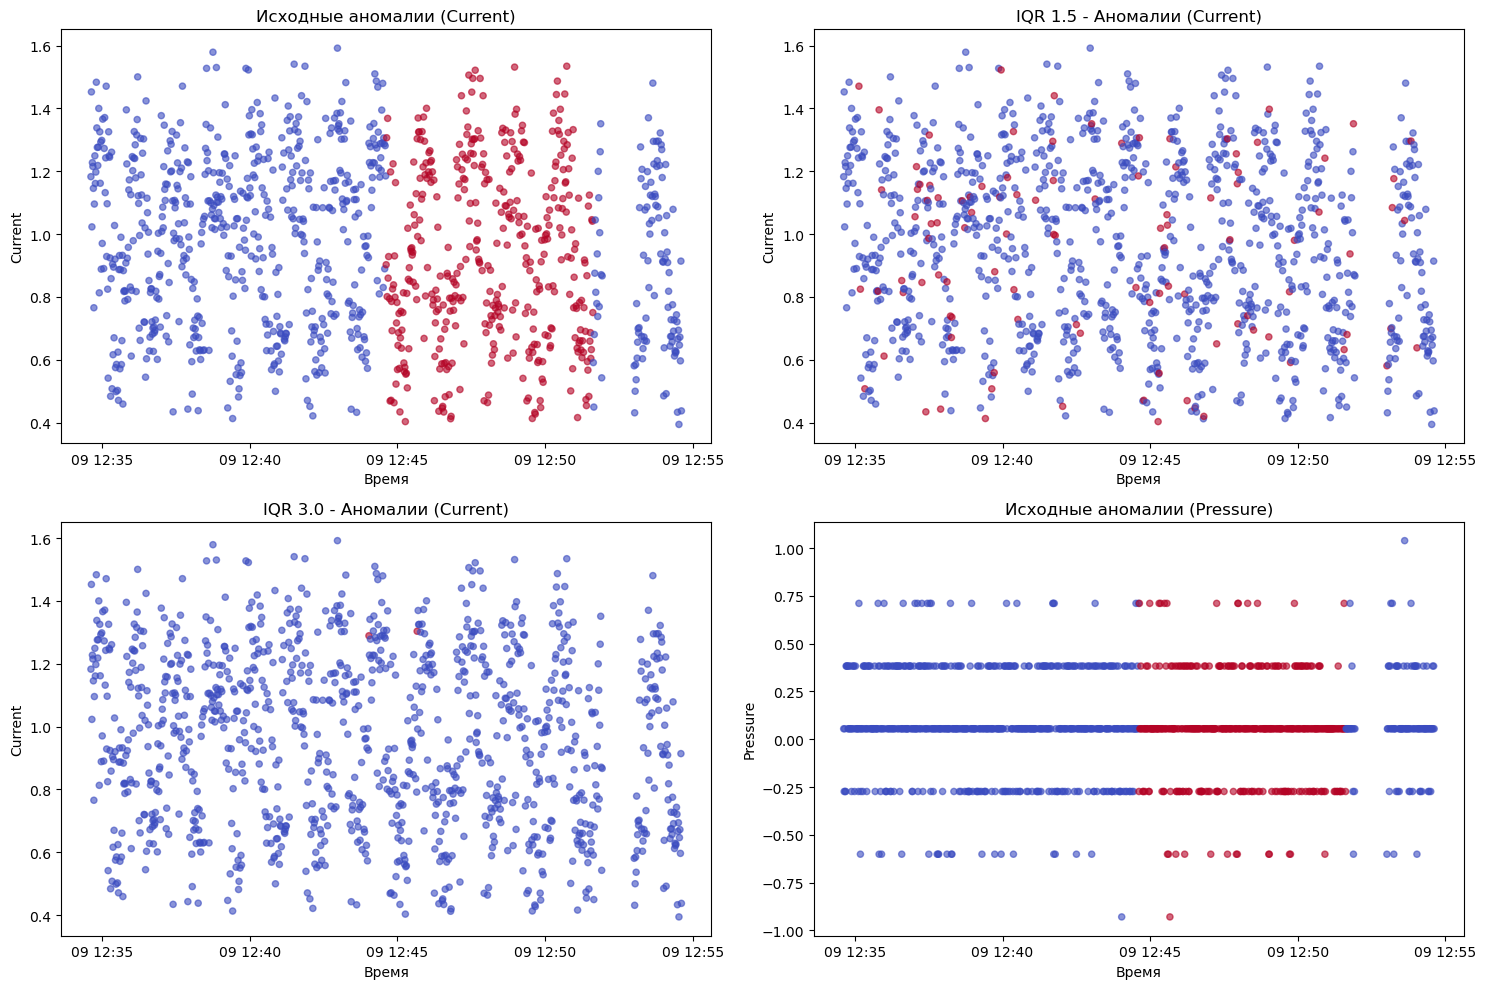

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Исходные аномалии
axes[0, 0].scatter(df['datetime'], df['Current'], 
                  c=df['anomaly'], cmap='coolwarm', alpha=0.6, s=20)
axes[0, 0].set_title('Исходные аномалии (Current)')
axes[0, 0].set_xlabel('Время')
axes[0, 0].set_ylabel('Current')

# IQR 1.5
axes[0, 1].scatter(df['datetime'], df['Current'], 
                  c=df['anomaly_iqr_1.5'], cmap='coolwarm', alpha=0.6, s=20)
axes[0, 1].set_title('IQR 1.5 - Аномалии (Current)')
axes[0, 1].set_xlabel('Время')
axes[0, 1].set_ylabel('Current')

# IQR 3.0
axes[1, 0].scatter(df['datetime'], df['Current'], 
                  c=df['anomaly_iqr_3.0'], cmap='coolwarm', alpha=0.6, s=20)
axes[1, 0].set_title('IQR 3.0 - Аномалии (Current)')
axes[1, 0].set_xlabel('Время')
axes[1, 0].set_ylabel('Current')

# Pressure для сравнения
axes[1, 1].scatter(df['datetime'], df['Pressure'], 
                  c=df['anomaly'], cmap='coolwarm', alpha=0.6, s=20)
axes[1, 1].set_title('Исходные аномалии (Pressure)')
axes[1, 1].set_xlabel('Время')
axes[1, 1].set_ylabel('Pressure')

plt.tight_layout()
plt.show()

In [19]:
def evaluate_anomaly_detection(true_labels, pred_labels, method_name):
    """
    Оценка качества обнаружения аномалий
    """
    cm = confusion_matrix(true_labels, pred_labels)
    precision = precision_score(true_labels, pred_labels)
    recall = recall_score(true_labels, pred_labels)
    f1 = f1_score(true_labels, pred_labels)
    
    print(f"\n{method_name}:")
    print(f"Confusion Matrix:\n{cm}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-Score: {f1:.3f}")
    
    return {'precision': precision, 'recall': recall, 'f1': f1}

# Оценка IQR методов
results = {}
results['IQR_1.5'] = evaluate_anomaly_detection(df['anomaly'], df['anomaly_iqr_1.5'], "IQR 1.5")
results['IQR_3.0'] = evaluate_anomaly_detection(df['anomaly'], df['anomaly_iqr_3.0'], "IQR 3.0")


IQR 1.5:
Confusion Matrix:
[[620  69]
 [369  36]]
Precision: 0.343
Recall: 0.089
F1-Score: 0.141

IQR 3.0:
Confusion Matrix:
[[688   1]
 [404   1]]
Precision: 0.500
Recall: 0.002
F1-Score: 0.005


In [20]:
def create_features(df):
    """
    Создание дополнительных признаков
    """
    df_fe = df.copy()
    
    # Признаки времени
    df_fe['hour'] = df_fe['datetime'].dt.hour
    df_fe['minute'] = df_fe['datetime'].dt.minute
    df_fe['second'] = df_fe['datetime'].dt.second
    
    # Лаги для ключевых параметров
    for feature in ['Current', 'Pressure', 'Temperature', 'Voltage']:
        df_fe[f'{feature}_lag1'] = df_fe[feature].shift(1)
        df_fe[f'{feature}_lag2'] = df_fe[feature].shift(2)
        df_fe[f'{feature}_lag3'] = df_fe[feature].shift(3)
    
    # Скользящие статистики
    window = 5
    for feature in ['Current', 'Pressure', 'Temperature']:
        df_fe[f'{feature}_rolling_mean'] = df_fe[feature].rolling(window=window).mean()
        df_fe[f'{feature}_rolling_std'] = df_fe[feature].rolling(window=window).std()
    
    # Разности
    for feature in ['Current', 'Pressure']:
        df_fe[f'{feature}_diff'] = df_fe[feature].diff()
    
    # Заполнение NaN значений
    df_fe = df_fe.fillna(method='bfill').fillna(method='ffill')
    
    return df_fe

# Создание признаков
df_fe = create_features(df)
print("Размерность данных после Feature Engineering:", df_fe.shape)

# Выбор признаков для кластеризации
clustering_features = [
    'Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 
    'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS',
    'hour', 'minute', 'Current_lag1', 'Pressure_lag1',
    'Current_rolling_mean', 'Pressure_rolling_mean'
]

X_cluster = df_fe[clustering_features]

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Кластеризация DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=10)
clusters = dbscan.fit_predict(X_scaled)

df_fe['cluster'] = clusters
df_fe['anomaly_dbscan'] = (clusters == -1).astype(int)

print(f"Кластеры: {np.unique(clusters)}")
print(f"Аномалий обнаружено DBSCAN: {df_fe['anomaly_dbscan'].sum()}")

Размерность данных после Feature Engineering: (1094, 36)
Кластеры: [-1]
Аномалий обнаружено DBSCAN: 1094


C:\Users\xxxxx\AppData\Local\Temp\ipykernel_9604\1947031493.py:29: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_fe = df_fe.fillna(method='bfill').fillna(method='ffill')


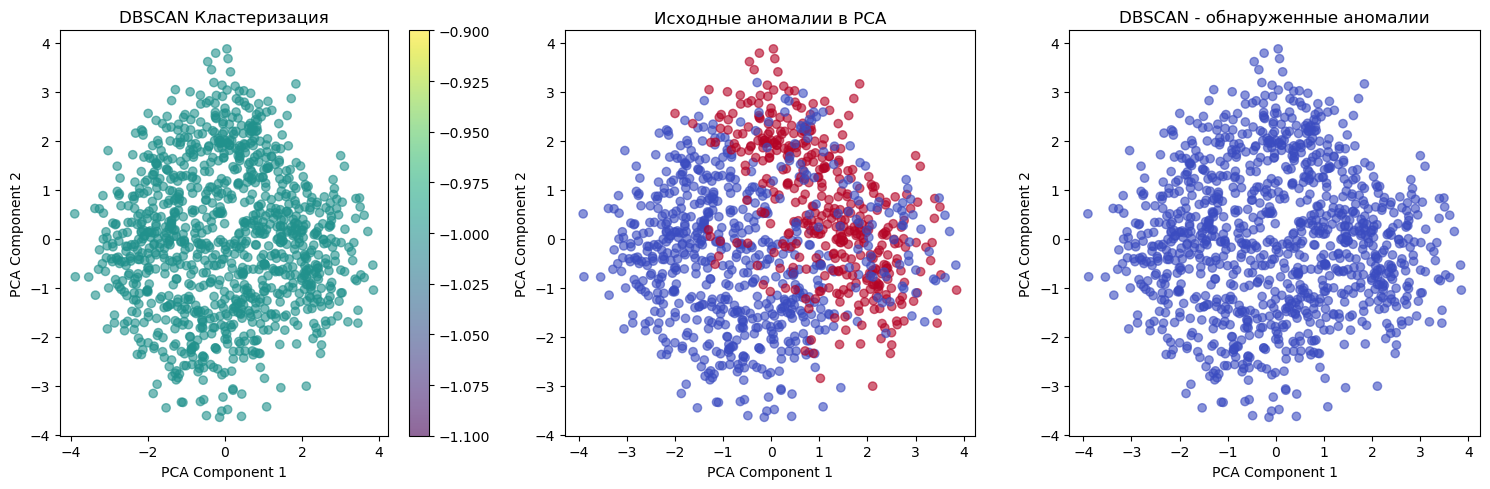

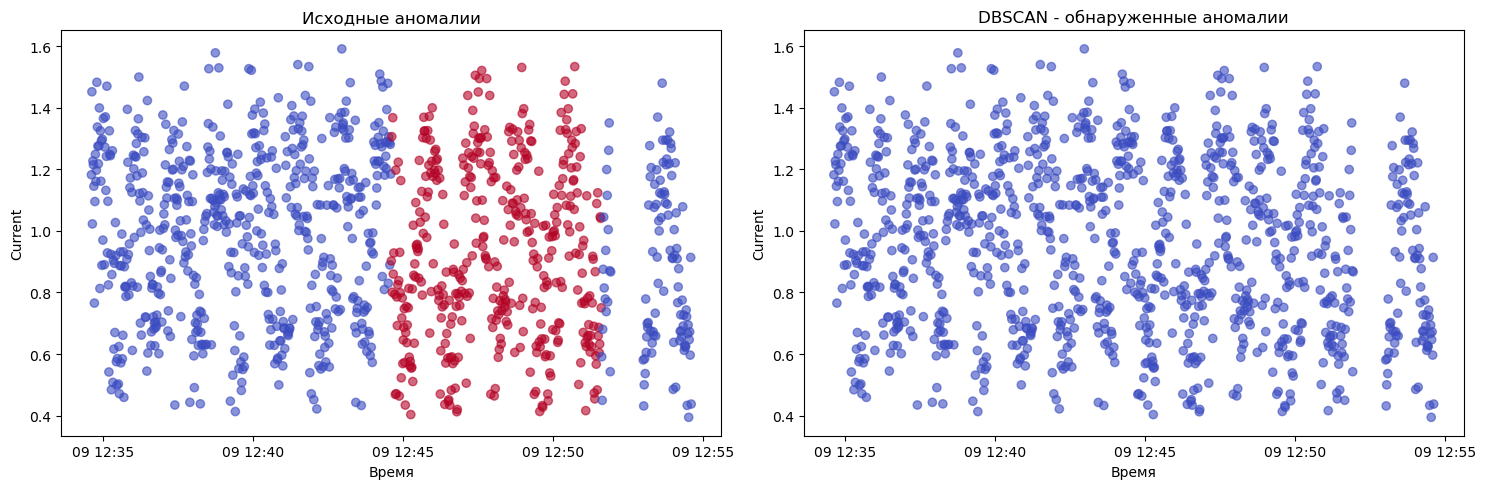

In [21]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(15, 5))

# Визуализация кластеров
plt.subplot(1, 3, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_fe['cluster'], 
                     cmap='viridis', alpha=0.6)
plt.colorbar(scatter)
plt.title('DBSCAN Кластеризация')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

# Исходные аномалии в PCA пространстве
plt.subplot(1, 3, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_fe['anomaly'], 
           cmap='coolwarm', alpha=0.6)
plt.title('Исходные аномалии в PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

# Предсказанные аномалии DBSCAN
plt.subplot(1, 3, 3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_fe['anomaly_dbscan'], 
           cmap='coolwarm', alpha=0.6)
plt.title('DBSCAN - обнаруженные аномалии')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.tight_layout()
plt.show()

# Временная визуализация
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.scatter(df_fe['datetime'], df_fe['Current'], 
           c=df_fe['anomaly'], cmap='coolwarm', alpha=0.6)
plt.title('Исходные аномалии')
plt.xlabel('Время')
plt.ylabel('Current')

plt.subplot(1, 2, 2)
plt.scatter(df_fe['datetime'], df_fe['Current'], 
           c=df_fe['anomaly_dbscan'], cmap='coolwarm', alpha=0.6)
plt.title('DBSCAN - обнаруженные аномалии')
plt.xlabel('Время')
plt.ylabel('Current')

plt.tight_layout()
plt.show()

In [22]:
results['DBSCAN'] = evaluate_anomaly_detection(df_fe['anomaly'], df_fe['anomaly_dbscan'], "DBSCAN")


DBSCAN:
Confusion Matrix:
[[  0 689]
 [  0 405]]
Precision: 0.370
Recall: 1.000
F1-Score: 0.540


In [23]:
iso_features = [
    'Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 
    'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS'
]

X_iso = df[iso_features]

# Масштабирование
scaler_iso = StandardScaler()
X_iso_scaled = scaler_iso.fit_transform(X_iso)

# Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42, n_estimators=100)
iso_predictions = iso_forest.fit_predict(X_iso_scaled)

# Преобразование предсказаний: -1 = аномалия, 1 = нормальная точка
df['anomaly_isolation'] = (iso_predictions == -1).astype(int)

print(f"Isolation Forest - обнаружено аномалий: {df['anomaly_isolation'].sum()}")

Isolation Forest - обнаружено аномалий: 110


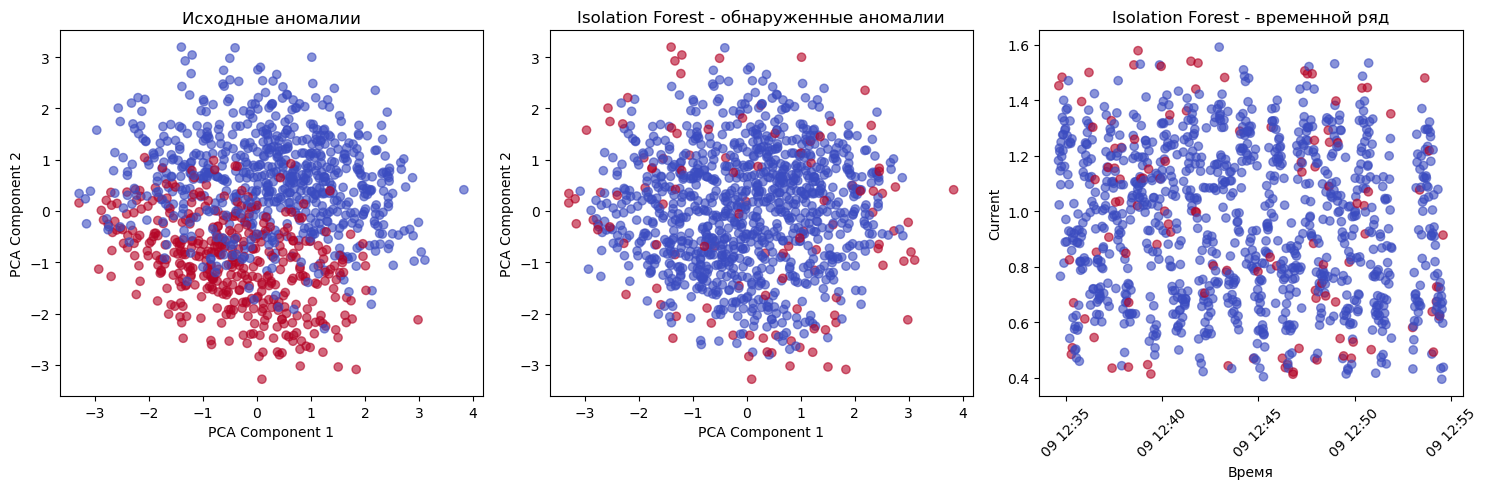

In [24]:
plt.figure(figsize=(15, 5))

# PCA для Isolation Forest
pca_iso = PCA(n_components=2)
X_iso_pca = pca_iso.fit_transform(X_iso_scaled)

plt.subplot(1, 3, 1)
plt.scatter(X_iso_pca[:, 0], X_iso_pca[:, 1], c=df['anomaly'], 
           cmap='coolwarm', alpha=0.6)
plt.title('Исходные аномалии')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.subplot(1, 3, 2)
plt.scatter(X_iso_pca[:, 0], X_iso_pca[:, 1], c=df['anomaly_isolation'], 
           cmap='coolwarm', alpha=0.6)
plt.title('Isolation Forest - обнаруженные аномалии')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

# Временной ряд
plt.subplot(1, 3, 3)
plt.scatter(df['datetime'], df['Current'], 
           c=df['anomaly_isolation'], cmap='coolwarm', alpha=0.6)
plt.title('Isolation Forest - временной ряд')
plt.xlabel('Время')
plt.ylabel('Current')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [25]:
results['Isolation_Forest'] = evaluate_anomaly_detection(df['anomaly'], df['anomaly_isolation'], "Isolation Forest")


Isolation Forest:
Confusion Matrix:
[[622  67]
 [362  43]]
Precision: 0.391
Recall: 0.106
F1-Score: 0.167


Сравнение всех методов:
                            method  precision  recall     f1
IQR_1.5                    IQR_1.5      0.343   0.089  0.141
IQR_3.0                    IQR_3.0      0.500   0.002  0.005
DBSCAN                      DBSCAN      0.370   1.000  0.540
Isolation_Forest  Isolation_Forest      0.391   0.106  0.167


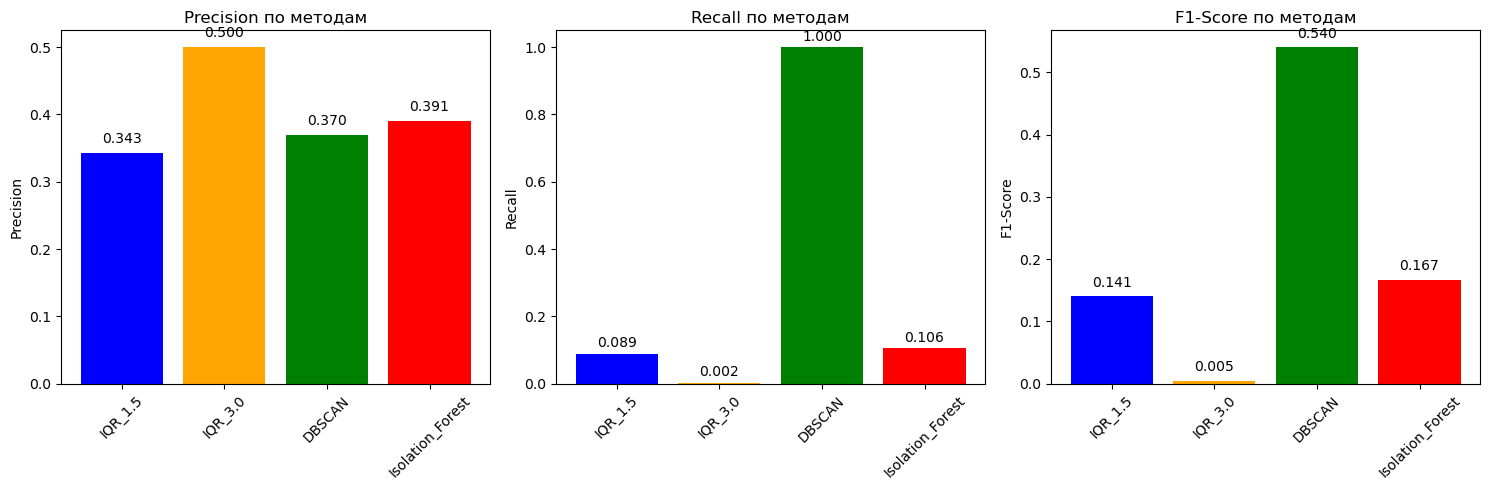

In [27]:
comparison_df = pd.DataFrame(results).T
comparison_df['method'] = comparison_df.index
comparison_df = comparison_df[['method', 'precision', 'recall', 'f1']]

print("Сравнение всех методов:")
print(comparison_df.round(3))

# Визуализация сравнения
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['precision', 'recall', 'f1']
titles = ['Precision', 'Recall', 'F1-Score']

for i, metric in enumerate(metrics):
    axes[i].bar(comparison_df['method'], comparison_df[metric], color=['blue', 'orange', 'green', 'red'])
    axes[i].set_title(f'{titles[i]} по методам')
    axes[i].set_ylabel(titles[i])
    axes[i].tick_params(axis='x', rotation=45)
    
    # Добавление значений на столбцы
    for j, v in enumerate(comparison_df[metric]):
        axes[i].text(j, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

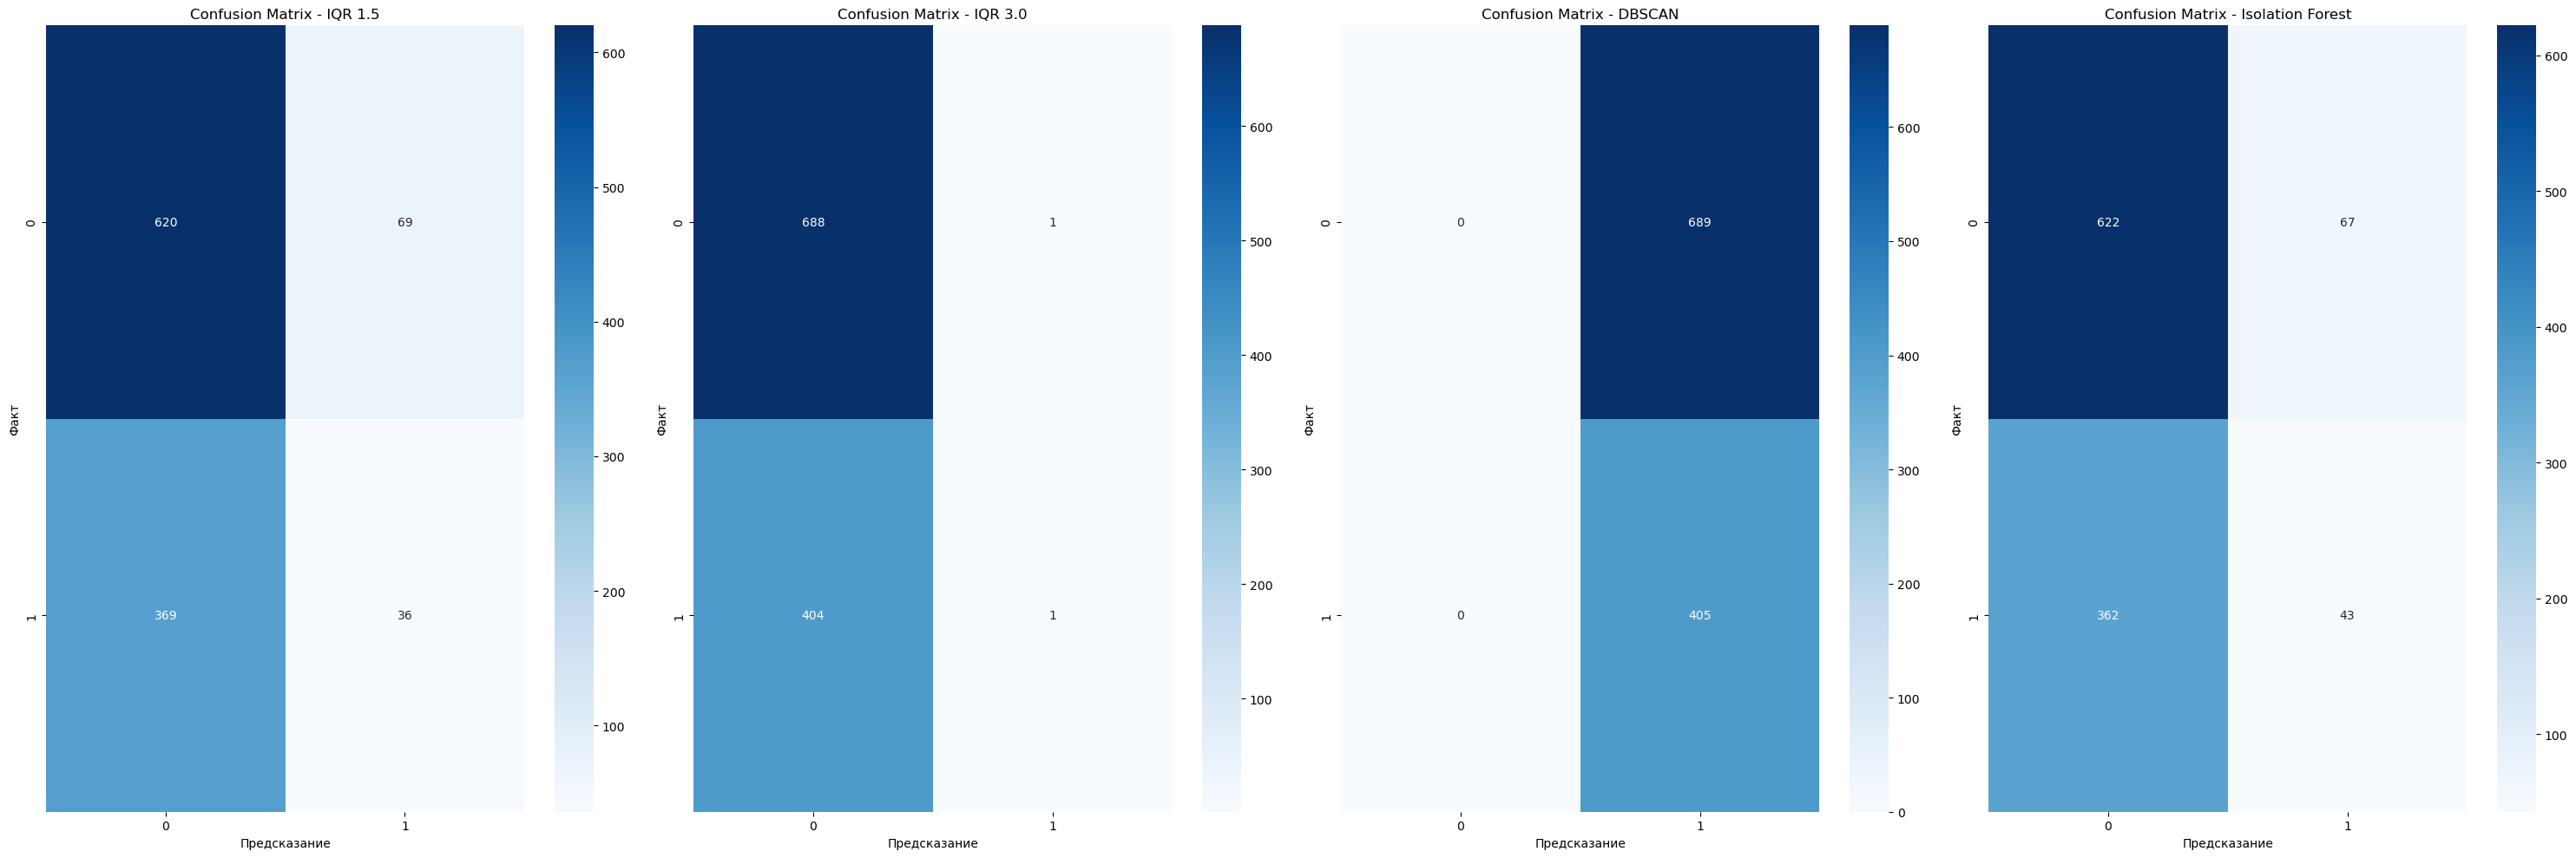

In [53]:
# Матрица сравнения методов
fig, axes = plt.subplots(1, 4, figsize=(30, 10))

cm = confusion_matrix(df['anomaly'], df['anomaly_iqr_1.5'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix - {'IQR 1.5'}')
axes[0].set_xlabel('Предсказание')
axes[0].set_ylabel('Факт')

cm = confusion_matrix(df['anomaly'], df['anomaly_iqr_3.0'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title(f'Confusion Matrix - {'IQR 3.0'}')
axes[1].set_xlabel('Предсказание')
axes[1].set_ylabel('Факт')

cm = confusion_matrix(df_fe['anomaly'], df_fe['anomaly_dbscan'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title(f'Confusion Matrix - {'DBSCAN'}')
axes[2].set_xlabel('Предсказание')
axes[2].set_ylabel('Факт')

cm = confusion_matrix(df['anomaly'], df['anomaly_isolation'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[3])
axes[3].set_title(f'Confusion Matrix - {'Isolation Forest'}')
axes[3].set_xlabel('Предсказание')
axes[3].set_ylabel('Факт')

plt.tight_layout()
plt.show()

In [50]:
comparison_df

,method,precision,recall,f1
IQR_1.5,IQR_1.5,0.342857,0.088889,0.141176
IQR_3.0,IQR_3.0,0.500000,0.002469,0.004914
DBSCAN,DBSCAN,0.370201,1.000000,0.540360
Isolation_Forest,Isolation_Forest,0.390909,0.106173,0.166990


In [29]:
best_method = comparison_df.loc[comparison_df['f1'].idxmax()]
print(f"\nЛучший метод: {best_method['method']}")
print(f"F1-Score: {best_method['f1']:.3f}")

# Анализ типов ошибок для лучшего метода
best_method_col = f"anomaly_{best_method['method'].lower().replace(' ', '_')}"

if best_method_col in df.columns:
    cm_best = confusion_matrix(df['anomaly'], df[best_method_col])
    tn, fp, fn, tp = cm_best.ravel()
    
    print(f"\nДетальный анализ {best_method['method']}:")
    print(f"True Positives (TP): {tp}")
    print(f"False Positives (FP): {fp}")
    print(f"True Negatives (TN): {tn}")
    print(f"False Negatives (FN): {fn}")
    print(f"Accuracy: {(tp + tn) / (tp + tn + fp + fn):.3f}")


Лучший метод: DBSCAN
F1-Score: 0.540


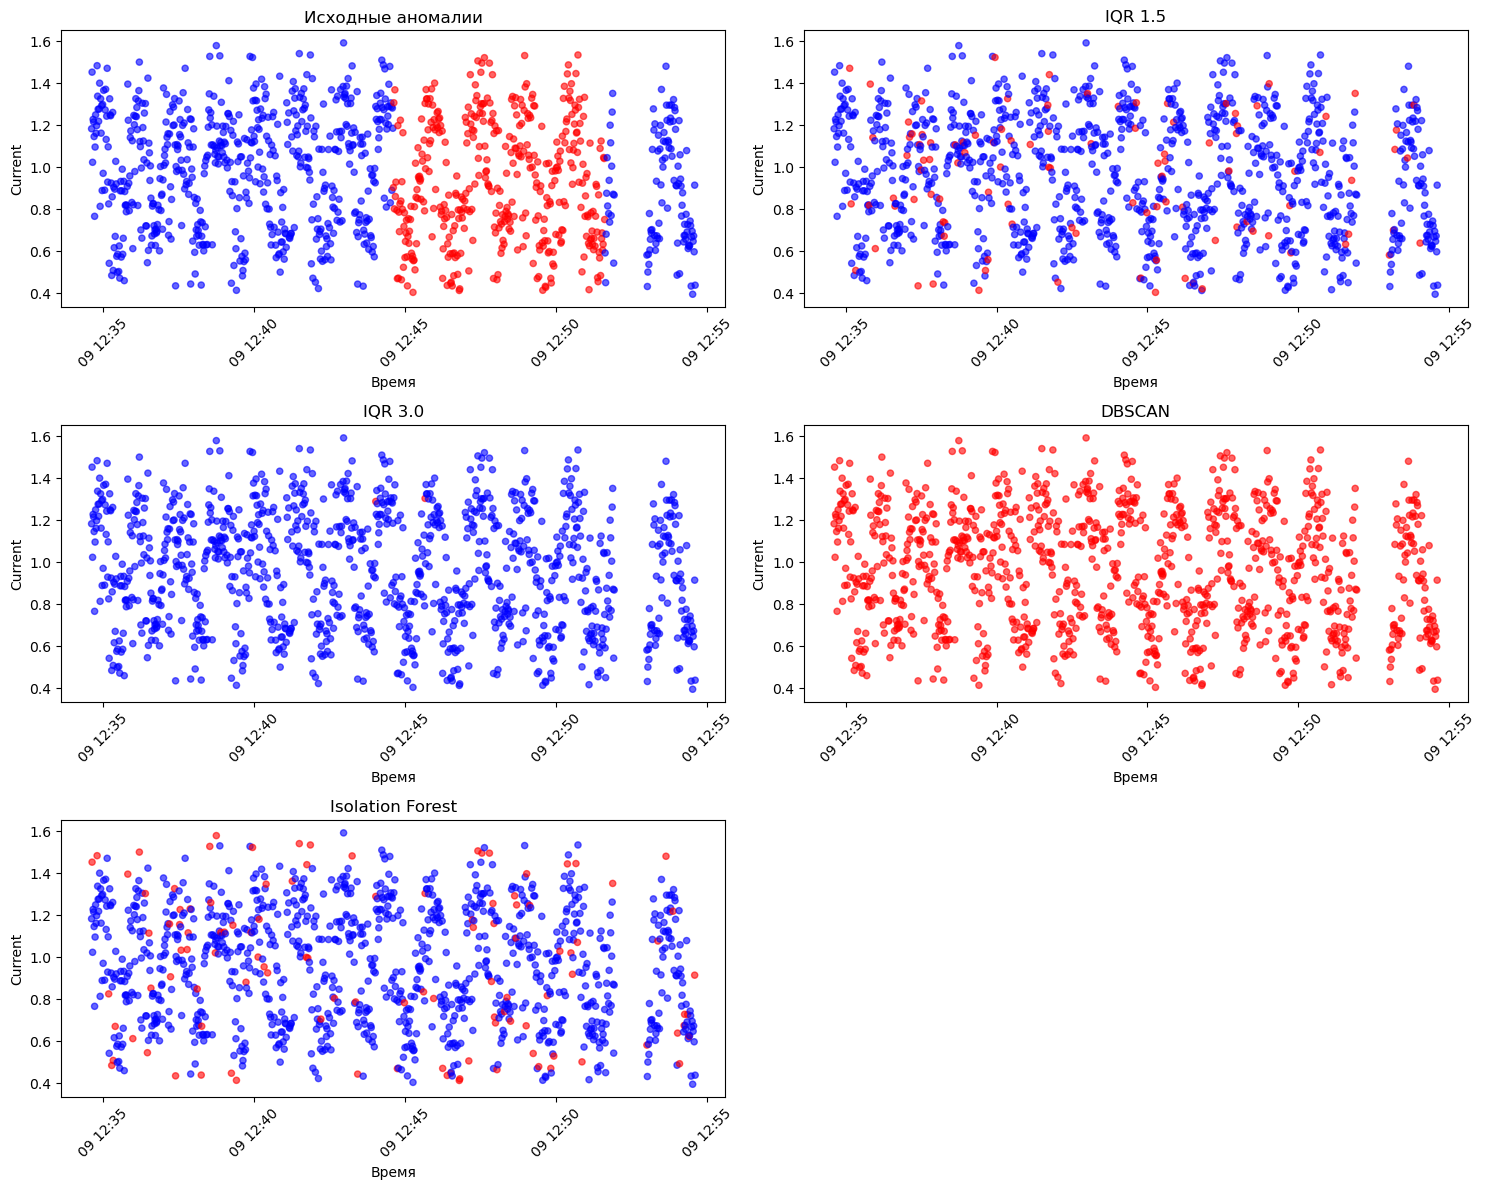

In [30]:
plt.figure(figsize=(15, 12))

methods_vis = [
    ('anomaly', 'Исходные аномалии'),
    ('anomaly_iqr_1.5', 'IQR 1.5'),
    ('anomaly_iqr_3.0', 'IQR 3.0'),
    ('anomaly_dbscan', 'DBSCAN'),
    ('anomaly_isolation', 'Isolation Forest')
]

for i, (method_col, title) in enumerate(methods_vis, 1):
    plt.subplot(3, 2, i)
    
    if method_col in df.columns:
        colors = ['blue' if x == 0 else 'red' for x in df[method_col]]
        plt.scatter(df['datetime'], df['Current'], c=colors, alpha=0.6, s=20)
    else:
        colors = ['blue' if x == 0 else 'red' for x in df_fe[method_col]]
        plt.scatter(df_fe['datetime'], df_fe['Current'], c=colors, alpha=0.6, s=20)
    
    plt.title(title)
    plt.xlabel('Время')
    plt.ylabel('Current')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()